# Import necessary libraries

In [13]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import math
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.base import BaseEstimator, RegressorMixin

# Remove warning 

In [14]:
import warnings
warnings.filterwarnings("ignore")

# Read Dataset

In [15]:
Data_folder = 'Dataset'

# Read  data
data_files = [os.path.join(Data_folder, file) for file in os.listdir(Data_folder) if file.endswith('.csv')]
df = pd.concat([pd.read_csv(file) for file in data_files], ignore_index=True)

In [16]:
df.shape

(84593, 186)

# Feature Selection

In [17]:
features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

In [18]:
df=df[features]

# Remove duplicate data points

In [19]:
# Remove duplicate rows and get the original DataFrame without duplicates
df_without_duplicates = df.drop_duplicates()
df=df_without_duplicates
df.shape

(77918, 11)

# Convert time string to seconds function

In [20]:
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df['OSD.flyTime'] = df['OSD.flyTime'].apply(time_to_seconds)


# Convert latitude and longitude into Cartesian coordinates

In [21]:
import pandas as pd
import math

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon
    
    # Convert the differences to meters using an appropriate conversion factor
    # For simplicity, assuming 1 degree of latitude = 111.32 km and 1 degree of longitude = 111.32 km * cos(latitude)
    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Assume 'df' is your DataFrame with columns 'OSD.latitude' and 'OSD.longitude'
# Define your local projection origin point
origin_lat = df['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df[['local_x', 'local_y']] = df.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Scale the Cartesian coordinates between -1 and 1 using Min-Max scaling
df['OSD.latitude'] = 2 * (df['local_x'] - df['local_x'].min()) / (df['local_x'].max() - df['local_x'].min()) - 1
df['OSD.longitude'] = 2 * (df['local_y'] - df['local_y'].min()) / (df['local_y'].max() - df['local_y'].min()) - 1

# Drop the 'local_x' and 'local_y' columns
df.drop(columns=['local_x', 'local_y'], inplace=True)

# Print the DataFrame
df.head()


,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0.0,1024,1024,1024,1024,0.999882,0.999001,0.0,5.7,2.5,113.9
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1


# Data Cleaning

### Remove Null values

In [22]:
null_counts = df.isnull().sum(axis=0)
print(null_counts)

OSD.flyTime        0
RC.aileron         0
RC.elevator        0
RC.throttle        0
RC.rudder          0
OSD.longitude      0
OSD.latitude       0
OSD.height [ft]    0
OSD.pitch          0
OSD.roll           0
OSD.yaw            0
dtype: int64


## Identify Outliers

# Handle the Outliers

In [23]:
def two_sided_median_filter(data, window_size):
    """
    Perform two-sided median filtering for outlier detection.

    Parameters:
    - data: 1D numpy array containing the flight data
    - window_size: Size of the window for median filtering

    Returns:
    - filtered_data: Numpy array with outliers replaced by the median value of neighboring elements
    """
    filtered_data = np.zeros_like(data)
    half_window = window_size // 2

    for i in range(len(data)):
        lower_bound = max(0, i - half_window)
        upper_bound = min(len(data), i + half_window + 1)

        window = data[lower_bound:upper_bound]
        if len(window) > 0:  # Check if window is not empty
            median = np.median(window)

            if data[i] < median - 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            elif data[i] > median + 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            else:
                filtered_data[i] = data[i]
        else:
            # If window is empty, set the filtered value to the original value
            filtered_data[i] = data[i]

    return filtered_data


# Apply two-sided median filtering to each feature
window_size = 7  # You can adjust the window size as needed
for feature in features:
    df[feature + '_filtered'] = two_sided_median_filter(df[feature].values, window_size)
    
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Identify outliers
outliers = df[residuals > threshold]

# Filter outliers
filtered_df = df[residuals <= threshold]

# Display the shape of the filtered DataFrame before and after removing outliers
print("Shape of original DataFrame:", df.shape)
print("Shape of filtered DataFrame (after removing outliers):", filtered_df.shape)

Shape of original DataFrame: (77918, 22)
Shape of filtered DataFrame (after removing outliers): (70086, 22)


In [24]:
df=filtered_df
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
5,0.5,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
84587,614.6,1024,1024,364,1024,-0.998368,-0.990697,1.6,5.2,0.0,-81.4
84588,614.7,1024,1024,364,1024,-0.998369,-0.990697,1.6,6.0,-0.4,-81.7
84589,614.8,1024,1024,364,1024,-0.998369,-0.990697,1.6,6.4,-0.4,-82.6
84590,614.9,1024,1024,364,1024,-0.998369,-0.990698,1.6,6.8,-0.4,-83.1


# Normalize other features

In [25]:
# Instantiate the StandardScaler
scaler = StandardScaler()

# Define the columns to normalize
columns_to_normalize = ['OSD.flyTime','RC.aileron','RC.elevator','RC.throttle','RC.rudder','OSD.longitude','OSD.latitude','OSD.height [ft]','OSD.pitch','OSD.roll','OSD.yaw']

# Apply StandardScaler to the specified columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,-1.429326,0.0282,-0.525247,0.125785,-0.004928,5.681611,5.679521,-0.581177,1.171226,1.3949,1.190752
2,-1.428975,0.0282,-0.525247,0.125785,-0.004928,5.681609,5.679522,-0.581177,1.171226,1.3949,1.190752
3,-1.428625,0.0282,-0.525247,0.125785,-0.004928,5.681609,5.679522,-0.581177,1.171226,1.3949,1.190752
4,-1.428274,0.0282,-0.525247,0.125785,-0.004928,5.681608,5.679521,-0.581177,1.171226,1.3949,1.191839
5,-1.427923,0.0282,-0.525247,0.125785,-0.004928,5.681608,5.679522,-0.581177,1.171226,1.3949,1.191839


In [ ]:
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape input data for LSTM
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Define the LSTM model
def create_lstm_model(layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential()
    model.add(LSTM(units=neurons, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
    model.add(Dense(units=len(output_targets)))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Define a wrapper class for the LSTM model
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001):
        self.layers = layers
        self.neurons = neurons
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.model = None

    def fit(self, X, y):
        self.model = create_lstm_model(layers=self.layers, neurons=self.neurons, dropout_rate=self.dropout_rate, learning_rate=self.learning_rate)
        self.model.fit(X, y, epochs=50, batch_size=32, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Create the hyperparameter grid
param_dist = {
    'layers': [1, 2, 3],
    'neurons': [32, 64, 128],
    'dropout_rate': [0.3, 0.5],
    'learning_rate': [0.001, 0.0001]
}

# Perform random search
random_search = RandomizedSearchCV(estimator=KerasRegressorWrapper(), param_distributions=param_dist, n_iter=10, scoring='neg_mean_squared_error', cv=3, verbose=2, random_state=42, n_jobs=1)

random_search.fit(X_train_lstm, y_train)

# Print best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

# Make predictions with best model
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_lstm)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)


In [26]:
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape input data for LSTM
# Assuming X_train and X_test are already defined
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Define the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(units=64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(Dense(units=len(output_targets)))  # Output layer

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32, verbose=1)

# Evaluate the model
mse_lstm = model_lstm.evaluate(X_test_lstm, y_test)

# Make predictions
y_pred_lstm = model_lstm.predict(X_test_lstm)




Epoch 1/50

1753/1753 [==============================] - 9s 3ms/step - loss: 0.8823
Epoch 2/50
1753/1753 [==============================] - 6s 4ms/step - loss: 0.8620
Epoch 3/50
1753/1753 [==============================] - 5s 3ms/step - loss: 0.8519
Epoch 4/50
1753/1753 [==============================] - 6s 3ms/step - loss: 0.8431
Epoch 5/50
1753/1753 [==============================] - 7s 4ms/step - loss: 0.8354
Epoch 6/50
1753/1753 [==============================] - 6s 3ms/step - loss: 0.8281
Epoch 7/50
1753/1753 [==============================] - 6s 4ms/step - loss: 0.8212
Epoch 8/50
1753/1753 [==============================] - 6s 3ms/step - loss: 0.8149
Epoch 9/50
1753/1753 [==============================] - 6s 3ms/step - loss: 0.8094
Epoch 10/50
1753/1753 [==============================] - 5s 3ms/step - loss: 0.8053
Epoch 11/50
1753/1753 [==============================] - 6s 3ms/step - loss: 0.8013
Epoch 12/50
1753/1753 [==============================] - 6s 4ms/step - loss: 0.797

31/31 [==============================] - 0s 3ms/step
OSD.longitude - Mean Squared Error: 8.91, R-squared: -14.80%, Mean Absolute Error: 2.18, Variance Explained: -14.80%
OSD.latitude - Mean Squared Error: 12.05, R-squared: -321.69%, Mean Absolute Error: 2.97, Variance Explained: -321.69%
OSD.height [ft] - Mean Squared Error: 3.59, R-squared: -520.74%, Mean Absolute Error: 1.81, Variance Explained: -520.74%
OSD.pitch - Mean Squared Error: 5.61, R-squared: -11.07%, Mean Absolute Error: 1.64, Variance Explained: -11.07%
OSD.roll - Mean Squared Error: 1.06, R-squared: -22.50%, Mean Absolute Error: 0.87, Variance Explained: -22.50%
OSD.yaw - Mean Squared Error: 9242.84, R-squared: -18.70%, Mean Absolute Error: 82.79, Variance Explained: -18.70%


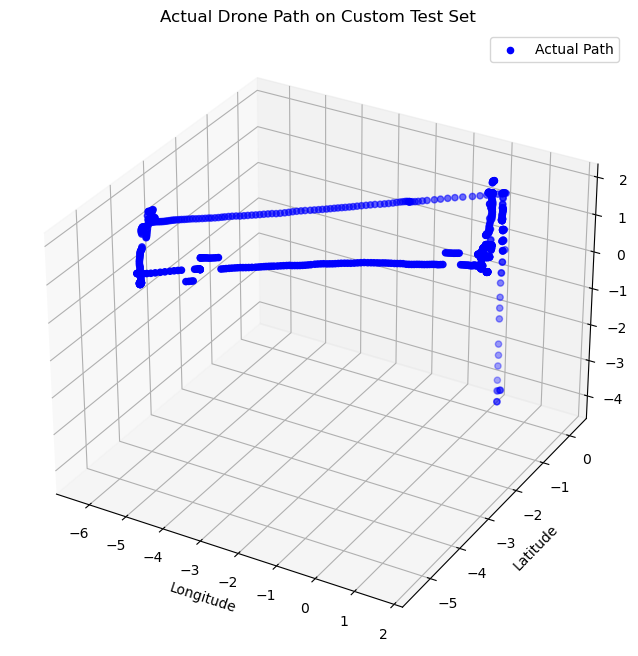

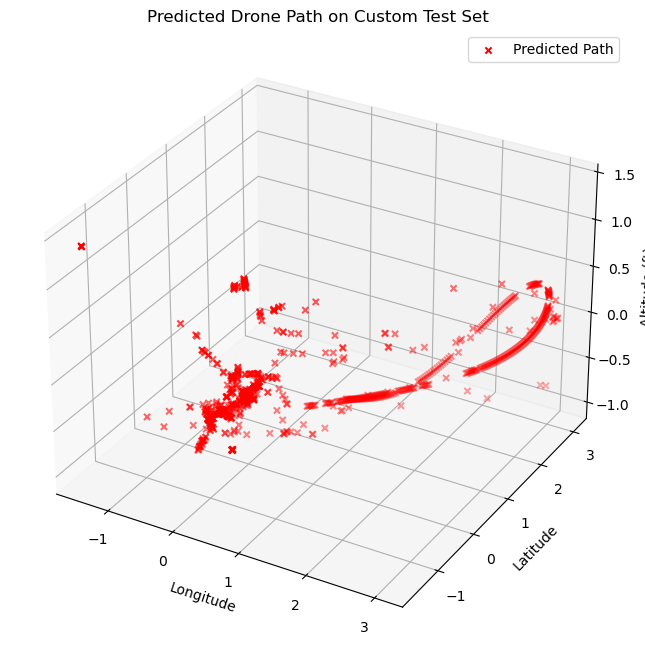

In [27]:
# Read the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Define your local projection origin point
origin_lat = df_test_custom['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df_test_custom['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df_test_custom[['local_x', 'local_y']] = df_test_custom.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Keep the latitude and longitude columns and replace their values with 'local_x' and 'local_y' respectively
df_test_custom['OSD.latitude'] = df_test_custom['local_x']
df_test_custom['OSD.longitude'] = df_test_custom['local_y']

# Drop the 'local_x' and 'local_y' columns if needed
df_test_custom.drop(columns=['local_x', 'local_y'], inplace=True)


features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']
df_test_custom=df_test_custom[features]

# Normalization using StandardScaler
scaler = StandardScaler()
df_test_custom_scaled = scaler.fit_transform(df_test_custom[['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']])

X_test_custom_scaled = df_test_custom_scaled[:, :5]  # Select the first 5 columns after scaling
X_test_custom_lstm = X_test_custom_scaled.reshape((X_test_custom_scaled.shape[0], 1, X_test_custom_scaled.shape[1]))

# Make predictions on the custom test set
y_pred_custom = model_lstm.predict(X_test_custom_lstm)

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom = mean_squared_error(df_test_custom[target_variable], y_pred_custom[:, i])
    r2_custom = r2_score(df_test_custom[target_variable], y_pred_custom[:, i])
    mae_custom = mean_absolute_error(df_test_custom[target_variable], y_pred_custom[:, i])
    variance_explained_custom = 100 * (1 - mse_custom / np.var(df_test_custom[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse_custom:.2f}, R-squared: {r2_custom:.2%}, Mean Absolute Error: {mae_custom:.2f}, Variance Explained: {variance_explained_custom:.2f}%')


# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()
